# Análisis de Datos 

# Trabajo práctico final



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
import missingno as msno
import statsmodels.api as sm
import folium
import json
from folium.plugins import HeatMap




Importa base

In [7]:
df = pd.read_csv("Crimes_-_2025_20260329.csv")

Algunos análisis preliminares

In [8]:
print(f"Dimensiones del dataset original: {df.shape}")
df.head()

Dimensiones del dataset original: (236849, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14075483,JK105557,12/31/2025 11:58:00 PM,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,...,20.0,61.0,08A,1165860.0,1871343.0,2025,03/14/2026 03:41:39 PM,"41,802549018","-87,667246428",POINT (-87.667246428 41.802549018)
1,14070833,JK100050,12/31/2025 11:55:00 PM,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,...,37.0,25.0,07,1140809.0,1900235.0,2025,03/14/2026 03:41:39 PM,"41,882328854","-87,758411303",POINT (-87.758411303 41.882328854)
2,14070745,JK100011,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,...,41.0,76.0,24,1100658.0,1934241.0,2025,03/14/2026 03:41:39 PM,"41,976290414","-87,905227221",POINT (-87.905227221 41.976290414)
3,14070799,JK100014,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,...,41.0,76.0,24,1100658.0,1934241.0,2025,03/14/2026 03:41:39 PM,"41,976290414","-87,905227221",POINT (-87.905227221 41.976290414)
4,14070845,JK100006,12/31/2025 11:54:00 PM,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,...,27.0,28.0,08B,1167120.0,1901555.0,2025,03/14/2026 03:41:39 PM,"41,885426714","-87,661759042",POINT (-87.661759042 41.885426714)


La base posee 22 columnas con 236849 filas. Cada fila representa un caso individual. 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236849 entries, 0 to 236848
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    236849 non-null  int64  
 1   Case Number           236849 non-null  object 
 2   Date                  236849 non-null  object 
 3   Block                 236849 non-null  object 
 4   IUCR                  236849 non-null  object 
 5   Primary Type          236849 non-null  object 
 6   Description           236849 non-null  object 
 7   Location Description  235736 non-null  object 
 8   Arrest                236849 non-null  bool   
 9   Domestic              236849 non-null  bool   
 10  Beat                  236849 non-null  int64  
 11  District              236849 non-null  int64  
 12  Ward                  236848 non-null  float64
 13  Community Area        236840 non-null  float64
 14  FBI Code              236849 non-null  object 
 15  

La base esta compuesta casi en su totalidad de variables categóricas

# Análisis de variables categóricas relevantes    

In [6]:
# Se convierten las columnas del dataset al tipo category
df['Primary Type'] = df['Primary Type'].astype('category')
df['Description'] = df['Description'].astype('category')
df['Location Description'] = df['Location Description'].astype('category')
df['Arrest'] = df['Arrest'].astype('category')
df['Domestic'] = df['Domestic'].astype('category')
df['Arrest'] = df['Arrest'].astype('category')
df['District'] = df['District'].astype('category')
df['FBI Code'] = df['FBI Code'].astype('category')


In [9]:
df.describe(include='category')

,Primary Type,Description,Location Description,Arrest,Domestic,District,FBI Code
count,236849,236849,235736,236849,236849,236849,236849
unique,31,316,130,2,2,23,26
top,THEFT,SIMPLE,STREET,False,False,8,06
freq,55089,30003,62276,198985,191730,15210,58616


Las variables  description y location description tienen cardinalidad relativamente alta.

Se grafican algunas de las variables categóticas

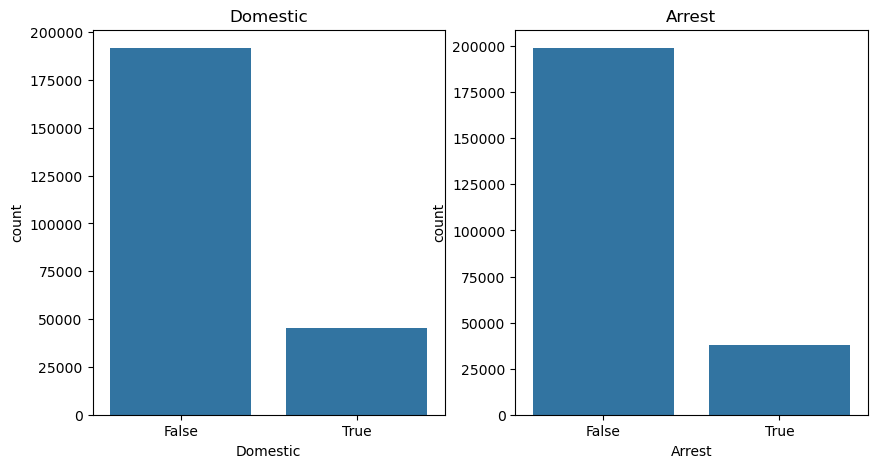

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x='Domestic', data=df, ax=ax[0])
sns.countplot(x='Arrest', data=df, ax=ax[1])

ax[0].set_title('Domestic')
ax[1].set_title('Arrest')

plt.show()

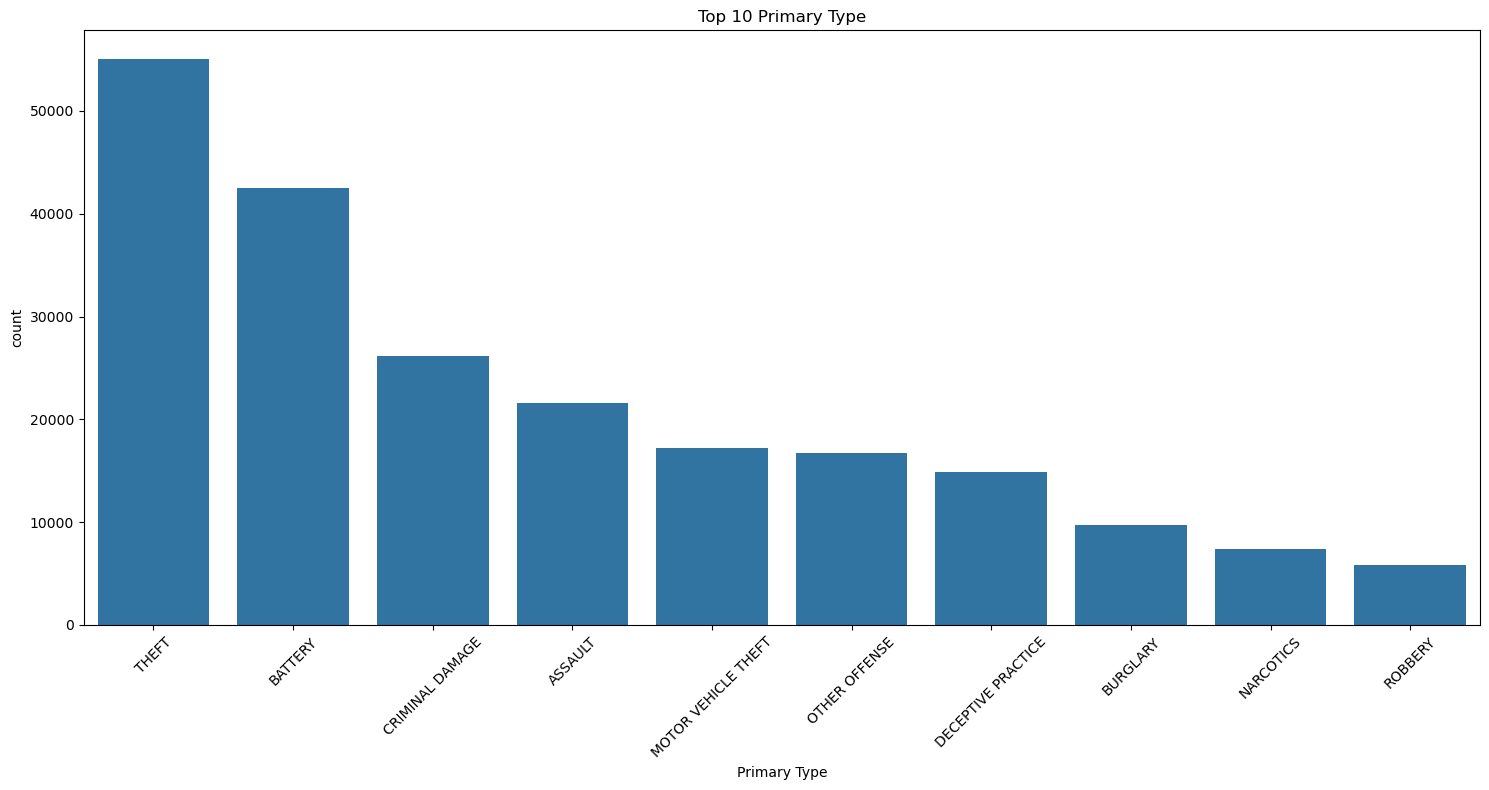

In [11]:
# Top 10 categorías más frecuentes
top = df['Primary Type'].value_counts().nlargest(10).index

fig, ax = plt.subplots(figsize=(15, 8))

sns.countplot(
    x='Primary Type',
    data=df[df['Primary Type'].isin(top)],
    order=top,
    ax=ax
)

# Título
ax.set_title('Top 10 Primary Type')

# Etiquetas en diagonal
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

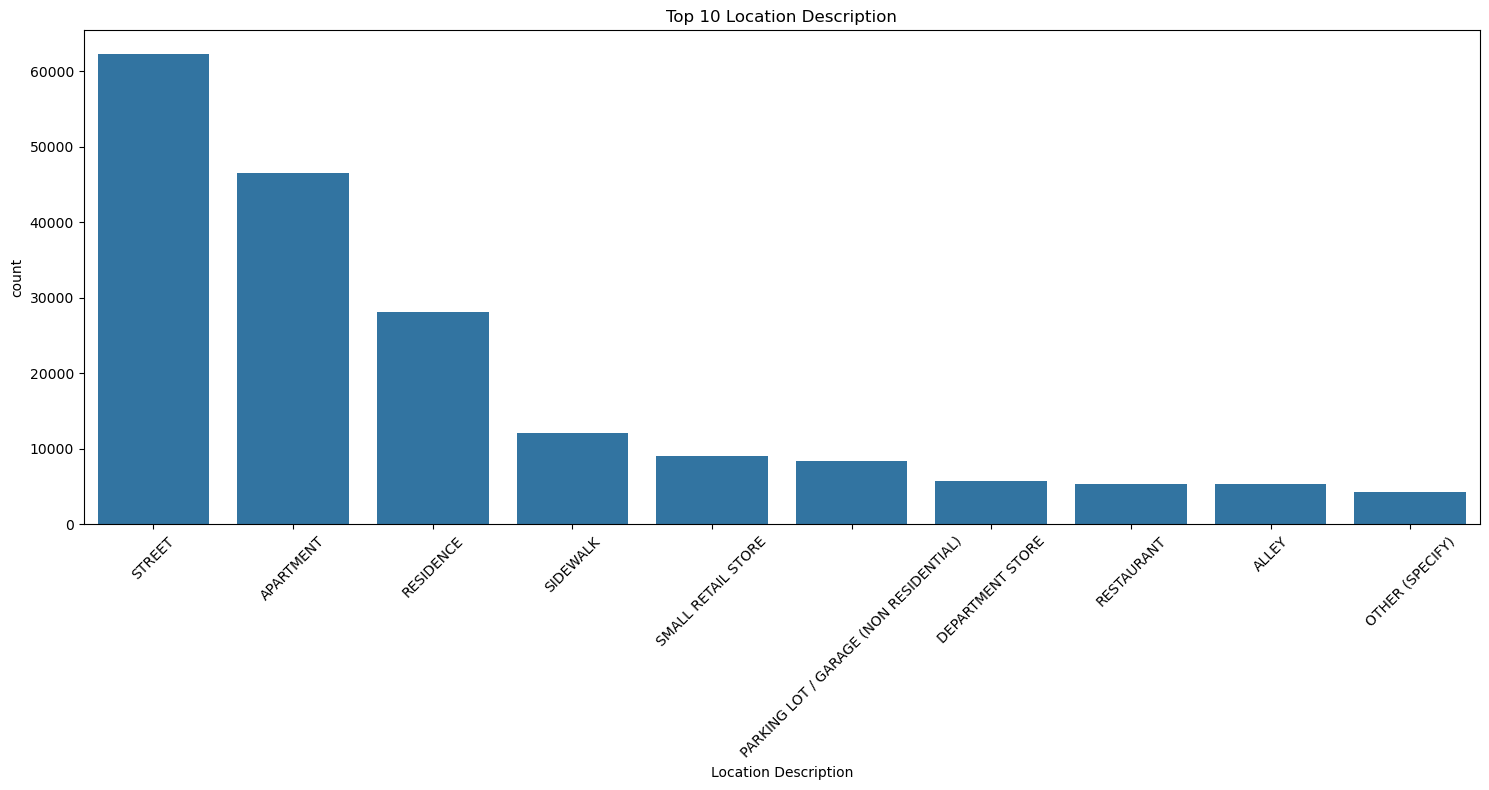

In [12]:
# Top 10 categorías más frecuentes
top = df['Location Description'].value_counts().nlargest(10).index

fig, ax = plt.subplots(figsize=(15, 8))

sns.countplot(
    x='Location Description',
    data=df[df['Location Description'].isin(top)],
    order=top,
    ax=ax
)

# Título
ax.set_title('Top 10 Location Description')

# Etiquetas en diagonal
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Se puede ver que hay location que son parecidas y se pordian unificar, como por ejemplo street y sidewalk

C:\Users\aye_c\AppData\Local\Temp\ipykernel_19024\905138570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


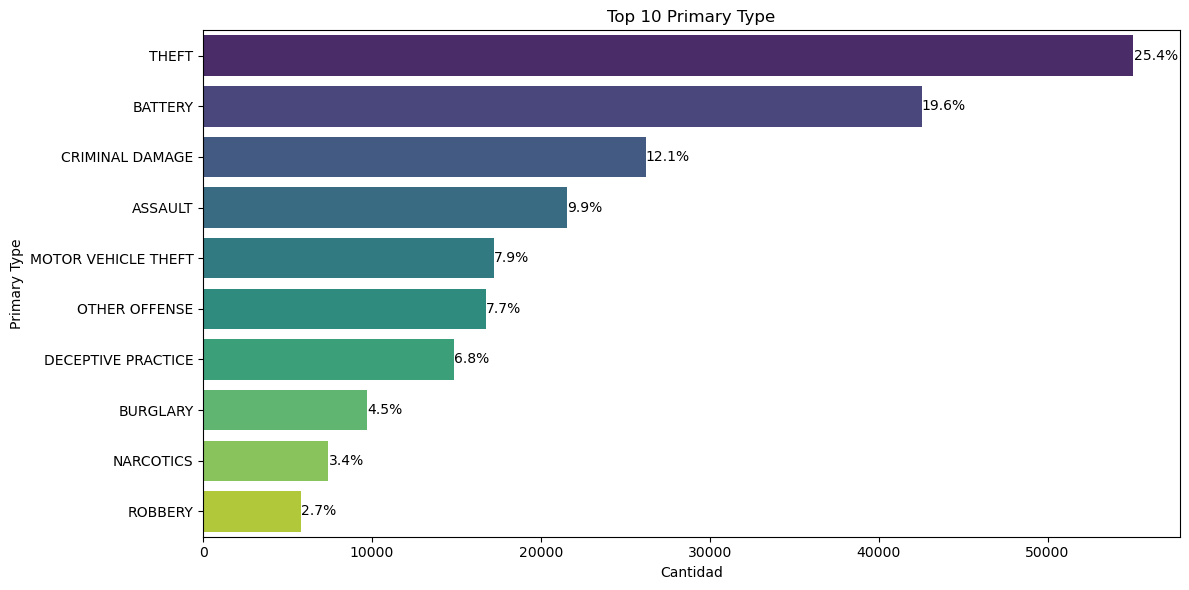

In [13]:
top_n = 10
top = df['Primary Type'].value_counts().nlargest(top_n).index

df_top = df[df['Primary Type'].isin(top)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_top,
    y='Primary Type',
    order=top,
    palette='viridis'
)

# Porcentajes
total = len(df_top)
for i, p in enumerate(ax.patches):
    value = p.get_width()
    ax.text(value + 5, i, f"{value/total*100:.1f}%", va='center')

plt.title(f'Top {top_n} Primary Type')
plt.xlabel('Cantidad')
plt.ylabel('Primary Type')

plt.tight_layout()
plt.show()

<Axes: xlabel='Arrest', ylabel='Domestic'>

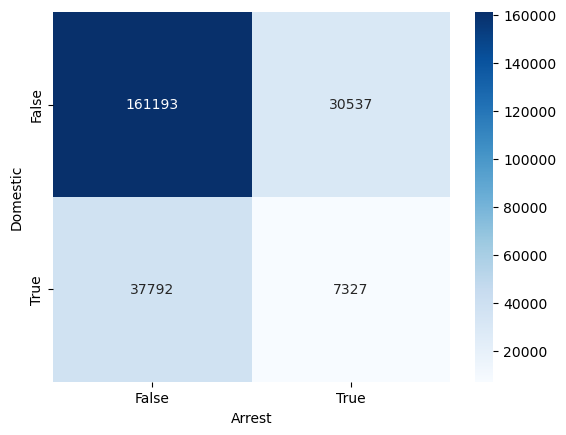

In [14]:
ct = pd.crosstab(df['Domestic'], df['Arrest'])

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

Evolución casos domesticos

In [23]:
df_dom = df[df["Domestic"] == True].copy()
df_dom["Date"] = pd.to_datetime(df_dom["Date"])

df_dom["mes"] = df_dom["Date"].dt.to_period("M")

df_mes = df_dom.groupby("mes").size().reset_index(name="cantidad")
df_mes = df_mes.sort_values("mes")

# convertir a timestamp para graficar bien
df_mes["mes"] = df_mes["mes"].dt.to_timestamp()

C:\Users\aye_c\AppData\Local\Temp\ipykernel_19416\3732665061.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_dom["Date"] = pd.to_datetime(df_dom["Date"])


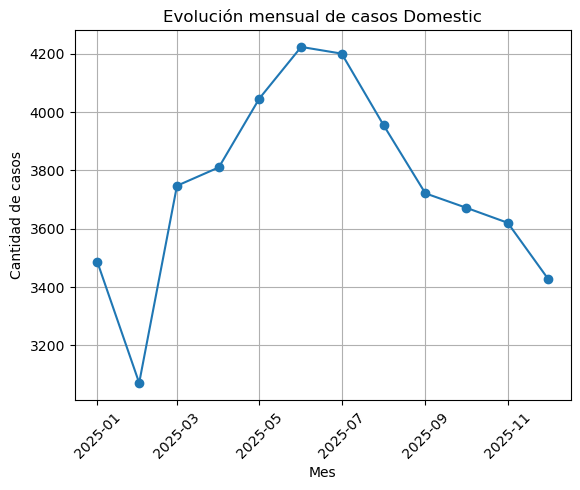

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_mes["mes"], df_mes["cantidad"], marker="o")

plt.xlabel("Mes")
plt.ylabel("Cantidad de casos")
plt.title("Evolución mensual de casos Domestic")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [25]:
df_mes

,mes,cantidad
0,2025-01-01,3486
1,2025-02-01,3071
2,2025-03-01,3747
3,2025-04-01,3810
4,2025-05-01,4046
5,2025-06-01,4223
6,2025-07-01,4200
7,2025-08-01,3955
8,2025-09-01,3721
9,2025-10-01,3672


Evolucion de arrestos

In [26]:
df_Arrest = df[df["Arrest"] == True].copy()
df_Arrest["Date"] = pd.to_datetime(df_Arrest["Date"])

df_Arrest["mes"] = df_Arrest["Date"].dt.to_period("M")

df_mes = df_Arrest.groupby("mes").size().reset_index(name="cantidad")
df_mes = df_mes.sort_values("mes")

# convertir a timestamp para graficar bien
df_mes["mes"] = df_mes["mes"].dt.to_timestamp()

C:\Users\aye_c\AppData\Local\Temp\ipykernel_19416\2700010711.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_Arrest["Date"] = pd.to_datetime(df_Arrest["Date"])


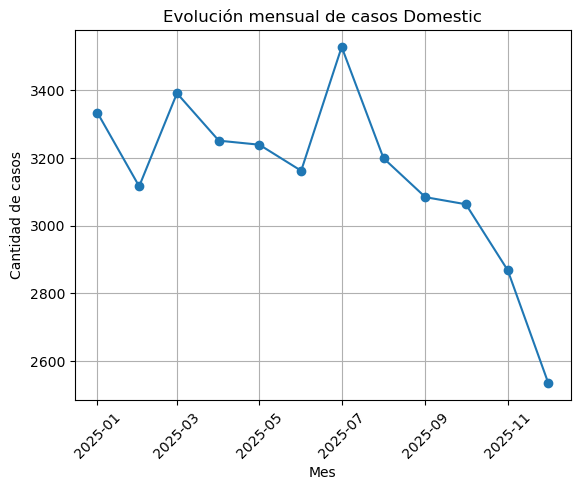

In [27]:
plt.figure()
plt.plot(df_mes["mes"], df_mes["cantidad"], marker="o")

plt.xlabel("Mes")
plt.ylabel("Cantidad de casos")
plt.title("Evolución mensual de casos Domestic")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [29]:
df_mes

,mes,cantidad
0,2025-01-01,3334
1,2025-02-01,3116
2,2025-03-01,3391
3,2025-04-01,3251
4,2025-05-01,3239
5,2025-06-01,3162
6,2025-07-01,3528
7,2025-08-01,3199
8,2025-09-01,3084
9,2025-10-01,3063


Cantidad de casos por distritos

In [15]:
df_count = df.groupby("District").size().reset_index(name="cantidad")
df_count = df_count.sort_values("cantidad", ascending=False)
pd.set_option('display.max_rows', None)

df_count

,District,cantidad
7,8,15160
11,12,14841
0,1,13635
5,6,13527
16,18,13158
3,4,13042
10,11,12895
2,3,12674
1,2,12660
17,19,12479


# Análisis de faltantes

In [ ]:
# Cuento valores nulos
df.isna().sum()  

ID                         0
Case Number                0
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description    1113
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       1
Community Area             9
FBI Code                   0
X Coordinate             729
Y Coordinate             729
Year                       0
Updated On                 0
Latitude                 729
Longitude                729
Location                 729
dtype: int64

Tenemos 7 variables con nulos: Location Description, ward,  X Coordinate, Y Coordinate, Latitude, Longitude y Location.

Qué tipo de datos faltantes son?

Se analiza: Location description

In [ ]:
df_missing = df[df['Location Description'].isna()]

df_missing.head()



,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
169,14083675,JK115613,12/31/2025 05:45:00 PM,048XX N SHERIDAN RD,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,NaN,False,False,...,46.0,3.0,11,1168755.0,1932522.0,2025,03/14/2026 03:41:39 PM,"41,970366453","-87,654855225",POINT (-87.654855225 41.970366453)
188,14070661,JJ540411,12/31/2025 04:50:00 PM,033XX N ASHLAND AVE,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,NaN,False,False,...,32.0,6.0,11,1165066.0,1922064.0,2025,03/14/2026 03:41:39 PM,"41,941748603","-87,668718084",POINT (-87.668718084 41.941748603)
202,14087072,JK119534,12/31/2025 04:08:00 PM,034XX N LAKE SHORE DR,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,NaN,False,False,...,44.0,6.0,11,1172449.0,1923411.0,2025,03/14/2026 03:41:39 PM,"41,945284535","-87,641542722",POINT (-87.641542722 41.945284535)
577,14075077,JK104572,12/30/2025 10:00:00 PM,005XX W ARLINGTON PL,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,43.0,7.0,11,1172257.0,1916656.0,2025,03/14/2026 03:41:39 PM,"41,926752802","-87,642448526",POINT (-87.642448526 41.926752802)
887,14069868,JJ539218,12/30/2025 09:45:00 AM,004XX N WABASH AVE,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,NaN,False,False,...,42.0,8.0,11,1176668.0,1903135.0,2025,03/14/2026 03:41:39 PM,"41,889551923","-87,626649565",POINT (-87.626649565 41.889551923)


Se observa si existe relacion con otras variables

In [ ]:
chequeo = df_missing.groupby('Description').size().sort_values(ascending=False)
print(chequeo.to_string())

Description
FINANCIAL IDENTITY THEFT OVER $ 300                             771
FINANCIAL IDENTITY THEFT $300 AND UNDER                         245
CREDIT CARD FRAUD                                                28
COMPUTER FRAUD                                                   20
FRAUD OR CONFIDENCE GAME                                         19
ILLEGAL USE CASH CARD                                            12
UNLAWFUL USE OF A COMPUTER                                        5
ATTEMPT - FINANCIAL IDENTITY THEFT                                3
FORGERY                                                           3
WIC FRAUD                                                         3
$500 AND UNDER                                                    2
AGGRAVATED - HANDGUN                                              1
COUNTERFEITING DOCUMENT                                           1
AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY        0
AGG. PROTECTED EMPLOYEE - HANDS, FIS

C:\Users\aye_c\AppData\Local\Temp\ipykernel_19024\3996757638.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chequeo = df_missing.groupby('Description').size().sort_values(ascending=False)


In [34]:
descripciones = [
    "FINANCIAL IDENTITY THEFT OVER",
    "FINANCIAL IDENTITY THEFT $300 AND UNDER",
    "CREDIT CARD FRAUD",
    "COMPUTER FRAUD",
    "FRAUD OR CONFIDENCE GAME",
    "ILLEGAL USE CASH CARD"
]

df_filtrado = df[df["Description"].isin(descripciones)]


In [35]:
df_filtrado.groupby("Description").size().sort_values(ascending=False)

Description
FRAUD OR CONFIDENCE GAME                   2793
CREDIT CARD FRAUD                          2155
ILLEGAL USE CASH CARD                      1203
FINANCIAL IDENTITY THEFT $300 AND UNDER    1053
COMPUTER FRAUD                              479
dtype: int64

La mayoria de los vacios son de tipo de crimen finanaciero o tecnológico, sin embargo no se regristra ninguan relación entre ambas variables. Pareciera que es un caso MCAR

Analisis para la variable ward:

In [ ]:
df_missing = df[df['Ward'].isna()]

df_missing.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
77392,13961276,JJ407553,08/31/2025 12:00:00 PM,026XX W 115TH ST,1187,DECEPTIVE PRACTICE,STATE BENEFITS FRAUD,RESIDENCE,False,False,...,NaN,NaN,11,1160919.0,1828275.0,2025,03/14/2026 03:41:39 PM,"41,684467361","-87,686554462",POINT (-87.686554462 41.684467361)


Pareciera ser error por omisión (MCAR) ya que tenemos las coordenadas del suceso. Se podria llenevar con el caso que se encuentre mas cercano en distancia. 

El resto de las variables con faltantes estan todas vinculadas, por lo que tiene sentido que falte la misma cantidad. Tomo location como variable representativa del grupo.

In [ ]:
df_missing = df[df['Location'].isna()]

df_missing.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
666,14148123,JK192448,12/30/2025 05:35:00 PM,007XX N ELIZABETH ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,APARTMENT,False,False,...,27.0,24.0,17,NaN,NaN,2025,03/27/2026 03:49:46 PM,NaN,NaN,NaN
6577,14147988,JK194658,12/20/2025 09:00:00 AM,034XX S RHODES AVE,0810,THEFT,OVER $500,APARTMENT,False,True,...,4.0,35.0,06,NaN,NaN,2025,03/27/2026 03:49:46 PM,NaN,NaN,NaN
8015,14147402,JK194020,12/17/2025 08:00:00 PM,072XX S KEDZIE AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,17.0,66.0,08B,NaN,NaN,2025,03/26/2026 03:43:32 PM,NaN,NaN,NaN
8368,14147960,JK194644,12/17/2025 09:00:00 AM,004XX E OAKWOOD BLVD,5002,OTHER OFFENSE,OTHER VEHICLE OFFENSE,STREET,False,True,...,3.0,38.0,26,NaN,NaN,2025,03/27/2026 03:49:46 PM,NaN,NaN,NaN
9247,14147534,JK194217,12/15/2025 05:35:00 PM,007XX W 61ST PL,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,16.0,68.0,11,NaN,NaN,2025,03/26/2026 03:43:32 PM,NaN,NaN,NaN


In [ ]:
chequeo = df_missing.groupby('Description').size().sort_values(ascending=False)
print(chequeo.to_string())

Description
SIMPLE                                                          88
OVER $500                                                       55
$500 AND UNDER                                                  50
DOMESTIC BATTERY SIMPLE                                         50
RETAIL THEFT                                                    47
FINANCIAL IDENTITY THEFT OVER $ 300                             45
TO VEHICLE                                                      39
AUTOMOBILE                                                      31
TO PROPERTY                                                     28
FROM BUILDING                                                   18
TELEPHONE THREAT                                                17
TO LAND                                                         12
HARASSMENT BY ELECTRONIC MEANS                                  11
HARASSMENT BY TELEPHONE                                         11
AGGRAVATED - OTHER DANGEROUS WEAPON               

C:\Users\aye_c\AppData\Local\Temp\ipykernel_19024\3996757638.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chequeo = df_missing.groupby('Description').size().sort_values(ascending=False)


No se encuentra relación del faltante con el tipo de delito. Pareciera ser otra variable del tipo MCAR. Una falta por azar y/o olvido de cargar la indormacion 

# Análisis de geolcalizacion. 

Se reemplazan comas por puntos y se eliminan los autliers de latitud y longitud

In [10]:
df["Latitude"] = pd.to_numeric(
    df["Latitude"].astype(str).str.replace(",", "."),
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"].astype(str).str.replace(",", "."),
    errors="coerce"
)

df = df.dropna(subset=["Latitude", "Longitude"])

In [11]:


mapa = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

heat_data = df[["Latitude", "Longitude"]].dropna().values.tolist()

HeatMap(heat_data).add_to(mapa)

mapa